In [1]:
import os, shutil
os.chdir("/Users/vince/CS163-Project")
shutil.rmtree("samples", ignore_errors=True)
print(os.getcwd())

/Users/vince/CS163-Project


In [2]:
# =========================
# Cell 1 — Imports + config
# =========================
import os
import gzip
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Set

import pandas as pd

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Folder containing UCSD/McAuley review files (.json.gz)
DATA_DIR = "data/"  # <-- change this

# Pick 5 categories (update filenames as needed)
CATEGORY_FILES = {
    "Electronics": "Electronics_5.json.gz",
    "Clothing, Shoes and Jewelry": "Clothing_Shoes_and_Jewelry_5.json.gz",
    "Tools and Home Improvement": "Tools_and_Home_Improvement_5.json.gz",
    "Toys_and_Games": "Toys_and_Games_5.json.gz",
    "Sports_and_Outdoors": "Sports_and_Outdoors_5.json.gz",
}

# Sampling constraints
N_PRODUCTS_PER_CATEGORY = 10_000
MIN_REVIEWS_PER_PRODUCT = 20
MIN_HISTORY_DAYS = 28  # 4 weeks

# Output folder
OUT_DIR = Path("samples")
OUT_DIR.mkdir(exist_ok=True)

SECONDS_PER_DAY = 86400

In [3]:
# ==========================================
# Cell 2 — Streaming reader + ASIN statistics
# ==========================================
@dataclass
class AsinStats:
    count: int = 0
    min_time: int = 2**63 - 1
    max_time: int = 0

def iter_reviews_jsonl_gz(path: str) -> Iterable[dict]:
    """Yield review dicts from a .json.gz file (JSON Lines)."""
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            yield json.loads(line)

def compute_asin_stats(path: str) -> Dict[str, AsinStats]:
    """1st pass: compute count/min/max unixReviewTime per ASIN."""
    stats: Dict[str, AsinStats] = {}
    for r in iter_reviews_jsonl_gz(path):
        asin = r.get("asin")
        t = r.get("unixReviewTime")
        if asin is None or t is None:
            continue
        s = stats.get(asin)
        if s is None:
            s = AsinStats()
            stats[asin] = s
        s.count += 1
        if t < s.min_time:
            s.min_time = t
        if t > s.max_time:
            s.max_time = t
    return stats

def eligible_asins(stats: Dict[str, AsinStats],
                   min_reviews: int,
                   min_history_days: int) -> List[str]:
    """Return ASINs meeting min review count and min history length."""
    min_span = min_history_days * SECONDS_PER_DAY
    return [
        asin for asin, s in stats.items()
        if s.count >= min_reviews and (s.max_time - s.min_time) >= min_span
    ]

def sample_asins(eligible: List[str], n: int) -> List[str]:
    """Sample n ASINs without replacement (or all if fewer than n)."""
    if len(eligible) <= n:
        return eligible
    return random.sample(eligible, n)

def load_reviews_for_asins(path: str, asins: Set[str]) -> pd.DataFrame:
    """2nd pass: load all reviews for selected ASINs into a DataFrame."""
    rows = []
    keep_keys = [
        "asin", "reviewerID", "overall", "reviewText", "summary",
        "unixReviewTime", "reviewTime", "verified", "vote", "style"
    ]
    for r in iter_reviews_jsonl_gz(path):
        asin = r.get("asin")
        if asin in asins:
            rows.append({k: r.get(k) for k in keep_keys})

    df = pd.DataFrame(rows)

    # Normalize common types
    if "unixReviewTime" in df.columns:
        df["unixReviewTime"] = pd.to_numeric(df["unixReviewTime"], errors="coerce")
        df["review_dt"] = pd.to_datetime(df["unixReviewTime"], unit="s", errors="coerce", utc=True)
    if "overall" in df.columns:
        df["overall"] = pd.to_numeric(df["overall"], errors="coerce")

    return df

In [4]:
# ======================================================
# Cell 3 — Run sampling per category (two-pass per file)
# ======================================================
results = {}

for cat, fname in CATEGORY_FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file for {cat}: {path}")

    print(f"\n=== Category: {cat} ===")
    print("Pass 1/2: computing per-ASIN stats...")
    stats = compute_asin_stats(path)
    print(f"Total unique ASINs seen: {len(stats):,}")

    elig = eligible_asins(stats, MIN_REVIEWS_PER_PRODUCT, MIN_HISTORY_DAYS)
    print(
        f"Eligible ASINs (>= {MIN_REVIEWS_PER_PRODUCT} reviews & "
        f">= {MIN_HISTORY_DAYS} days history): {len(elig):,}"
    )

    sampled = sample_asins(elig, N_PRODUCTS_PER_CATEGORY)
    print(f"Sampled ASINs: {len(sampled):,}")

    print("Pass 2/2: loading reviews for sampled ASINs into pandas...")
    df = load_reviews_for_asins(path, set(sampled))
    print(f"Loaded reviews: {len(df):,}")

    # Sanity checks at product level
    prod_counts = df.groupby("asin")["overall"].size()
    prod_span_days = (df.groupby("asin")["unixReviewTime"].max() -
                      df.groupby("asin")["unixReviewTime"].min()) / SECONDS_PER_DAY

    print(f"Products with >= {MIN_REVIEWS_PER_PRODUCT} reviews: {(prod_counts >= MIN_REVIEWS_PER_PRODUCT).sum():,} / {prod_counts.size:,}")
    print(f"Products with >= {MIN_HISTORY_DAYS} days span: {(prod_span_days >= MIN_HISTORY_DAYS).sum():,} / {prod_span_days.size:,}")

    # Save outputs
    cat_dir = OUT_DIR / cat
    cat_dir.mkdir(parents=True, exist_ok=True)

    asin_path = cat_dir / "sample_asins.csv"
    pd.Series(sampled, name="asin").to_csv(asin_path, index=False)

    parquet_path = cat_dir / "sample_reviews.parquet"
    df.to_parquet(parquet_path, index=False)

    results[cat] = {
        "asin_count": len(sampled),
        "review_rows": len(df),
        "asin_list_path": str(asin_path),
        "reviews_path": str(parquet_path),
    }

summary = pd.DataFrame(results).T
summary


=== Category: Electronics ===
Pass 1/2: computing per-ASIN stats...
Total unique ASINs seen: 160,052
Eligible ASINs (>= 20 reviews & >= 28 days history): 57,182
Sampled ASINs: 10,000
Pass 2/2: loading reviews for sampled ASINs into pandas...
Loaded reviews: 996,919
Products with >= 20 reviews: 10,000 / 10,000
Products with >= 28 days span: 10,000 / 10,000

=== Category: Clothing, Shoes and Jewelry ===
Pass 1/2: computing per-ASIN stats...
Total unique ASINs seen: 376,858
Eligible ASINs (>= 20 reviews & >= 28 days history): 103,146
Sampled ASINs: 10,000
Pass 2/2: loading reviews for sampled ASINs into pandas...
Loaded reviews: 833,344
Products with >= 20 reviews: 10,000 / 10,000
Products with >= 28 days span: 10,000 / 10,000

=== Category: Tools and Home Improvement ===
Pass 1/2: computing per-ASIN stats...
Total unique ASINs seen: 73,649
Eligible ASINs (>= 20 reviews & >= 28 days history): 22,885
Sampled ASINs: 10,000
Pass 2/2: loading reviews for sampled ASINs into pandas...
Loaded r

,asin_count,review_rows,asin_list_path,reviews_path
Electronics,10000,996919,samples/Electronics/sample_asins.csv,samples/Electronics/sample_reviews.parquet
"Clothing, Shoes and Jewelry",10000,833344,"samples/Clothing, Shoes and Jewelry/sample_asi...","samples/Clothing, Shoes and Jewelry/sample_rev..."
Tools and Home Improvement,10000,693873,samples/Tools and Home Improvement/sample_asin...,samples/Tools and Home Improvement/sample_revi...
Toys_and_Games,10000,595796,samples/Toys_and_Games/sample_asins.csv,samples/Toys_and_Games/sample_reviews.parquet
Sports_and_Outdoors,10000,701443,samples/Sports_and_Outdoors/sample_asins.csv,samples/Sports_and_Outdoors/sample_reviews.par...


In [5]:
# ==========================================
# Cell 4 — Optional: combine into one dataset
# ==========================================
dfs = []
for cat in CATEGORY_FILES.keys():
    p = OUT_DIR / cat / "sample_reviews.parquet"
    d = pd.read_parquet(p)
    d["category"] = cat
    dfs.append(d)

all_reviews = pd.concat(dfs, ignore_index=True)
all_reviews.shape

(3821375, 12)

In [6]:
import pandas as pd
from pathlib import Path

SAMPLES_DIR = Path("samples")

ratings = []
review_counts = []

for category_dir in SAMPLES_DIR.iterdir():
    if not category_dir.is_dir():
        continue

    file_path = category_dir / "sample_reviews.parquet"

    # Load only columns we need
    df = pd.read_parquet(file_path, columns=["asin", "overall"])

    # Collect ratings
    ratings.append(df["overall"].dropna())

    # Compute review counts per product for this category
    counts = df.groupby("asin").size()
    review_counts.append(counts)

# Combine small Series (safe)
ratings = pd.concat(ratings)
review_counts = pd.concat(review_counts)

In [7]:
# Rating statistics
mean_rating = ratings.mean()
median_rating = ratings.median()
std_rating = ratings.std()

# Product-level review count statistics
mean_review_count = review_counts.mean()
median_review_count = review_counts.median()

print("Mean rating:", mean_rating)
print("Median rating:", median_rating)
print("Standard deviation of ratings:", std_rating)
print("Mean review count per product:", mean_review_count)
print("Median review count per product:", median_review_count)

Mean rating: 4.368376042654804
Median rating: 5.0
Standard deviation of ratings: 1.0946008237774154
Mean review count per product: 76.4275
Median review count per product: 39.0


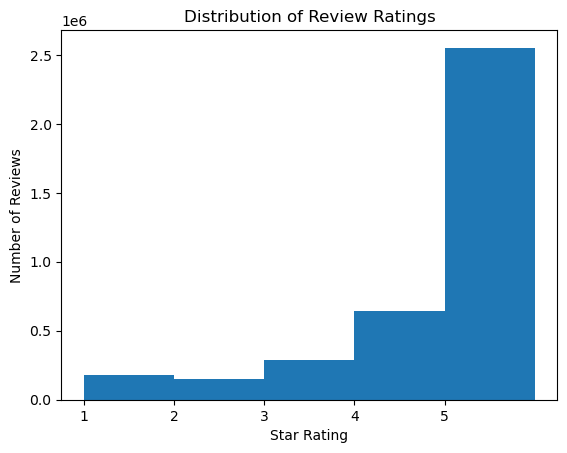

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.hist(ratings, bins=[1,2,3,4,5,6])
plt.title("Distribution of Review Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks([1,2,3,4,5])
plt.show()

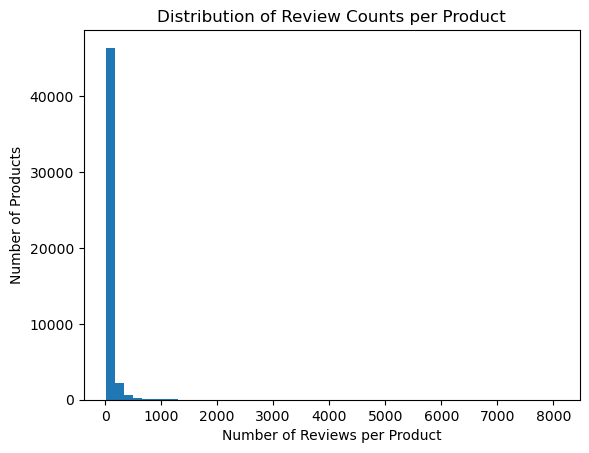

In [9]:
plt.figure()
plt.hist(review_counts, bins=50)
plt.title("Distribution of Review Counts per Product")
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.show()

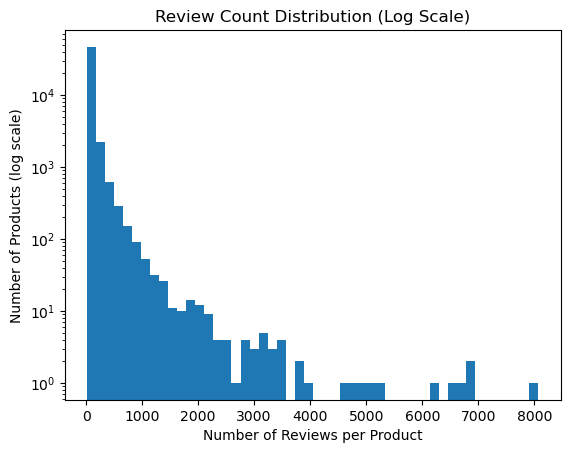

In [10]:
plt.figure()
plt.hist(review_counts, bins=50)
plt.yscale("log")
plt.title("Review Count Distribution (Log Scale)")
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products (log scale)")
plt.show()

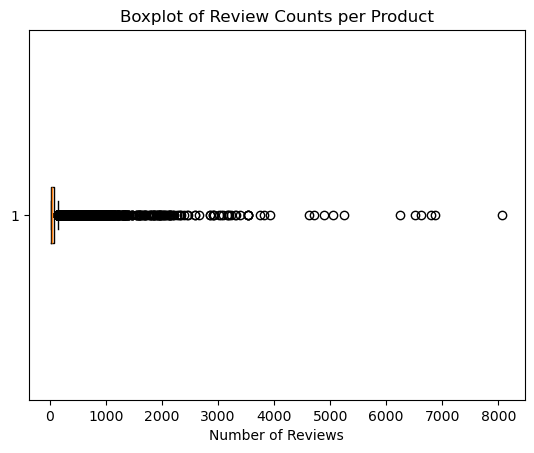

In [11]:
plt.figure()
plt.boxplot(review_counts, vert=False)
plt.title("Boxplot of Review Counts per Product")
plt.xlabel("Number of Reviews")
plt.show()

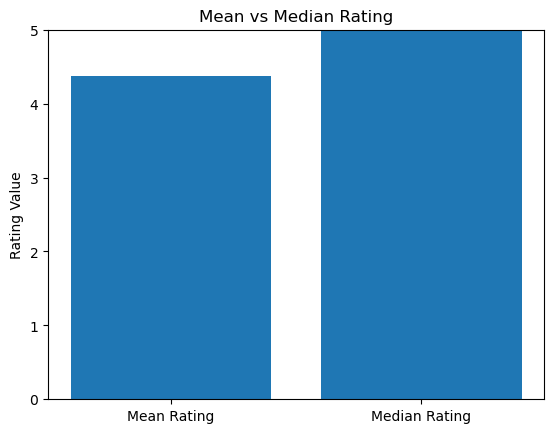

In [12]:
stats = [mean_rating, median_rating]
labels = ["Mean Rating", "Median Rating"]

plt.figure()
plt.bar(labels, stats)
plt.title("Mean vs Median Rating")
plt.ylabel("Rating Value")
plt.ylim(0,5)
plt.show()

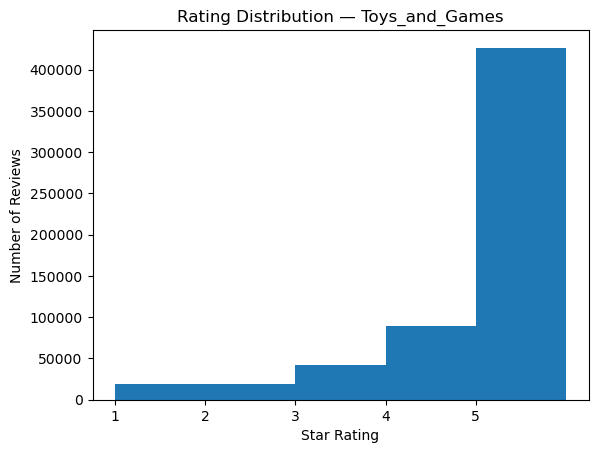

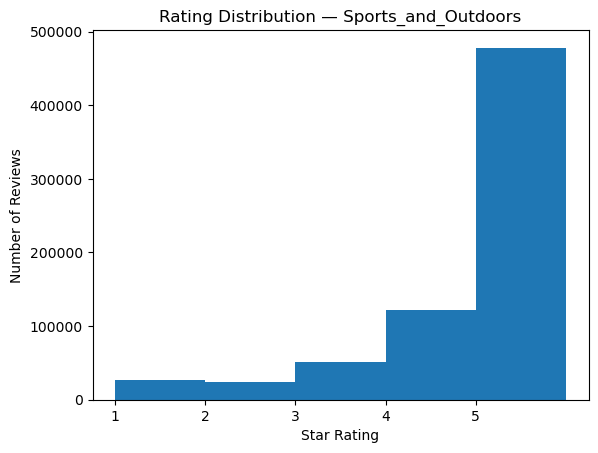

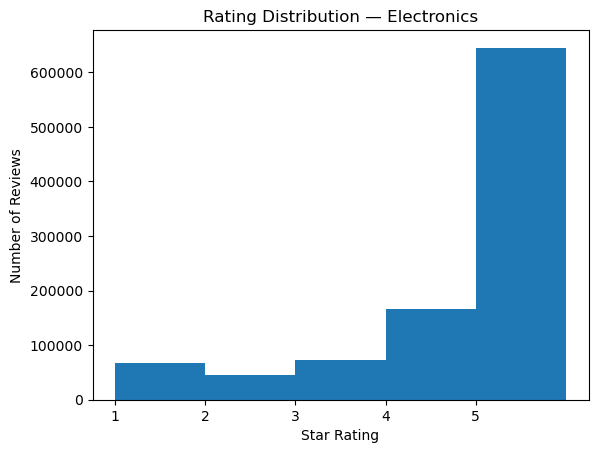

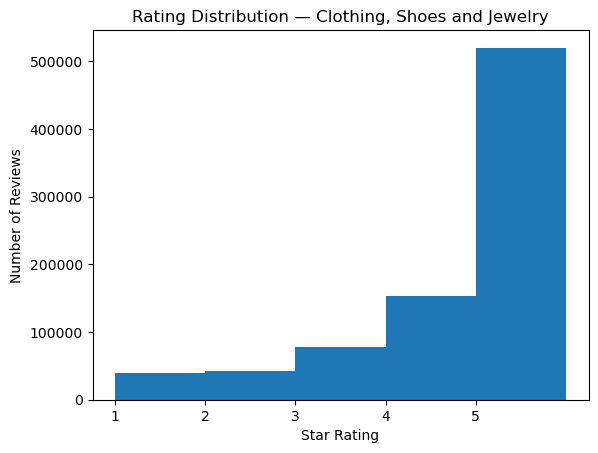

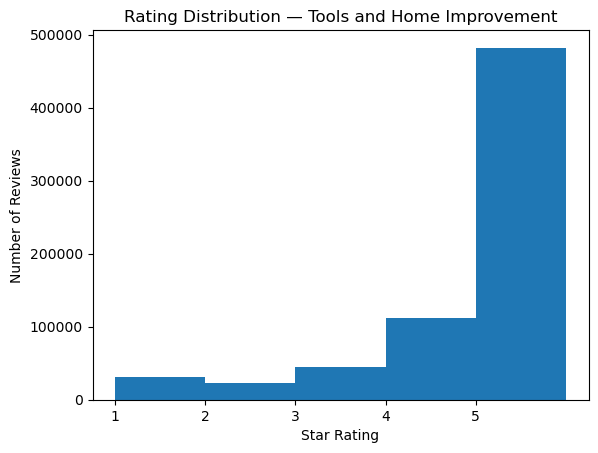

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

SAMPLES_DIR = Path("samples")

# Get list of category folders first
category_dirs = [d for d in SAMPLES_DIR.iterdir() if d.is_dir()]

for category_dir in category_dirs:
    file_path = category_dir / "sample_reviews.parquet"

    df_cat = pd.read_parquet(file_path, columns=["overall"])

    fig, ax = plt.subplots()
    ax.hist(df_cat["overall"].dropna(), bins=[1,2,3,4,5,6])
    ax.set_title(f"Rating Distribution — {category_dir.name}")
    ax.set_xlabel("Star Rating")
    ax.set_ylabel("Number of Reviews")
    ax.set_xticks([1,2,3,4,5])

    plt.show()   # <-- ensures each plot renders
    plt.close(fig)  # <-- prevents memory buildup

In [14]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

os.chdir("/Users/vince/CS163-Project")
print(os.getcwd())

SAMPLES_DIR = Path("samples")
print(list(SAMPLES_DIR.iterdir()))

/Users/vince/CS163-Project
[PosixPath('samples/Toys_and_Games'), PosixPath('samples/Sports_and_Outdoors'), PosixPath('samples/Electronics'), PosixPath('samples/Clothing, Shoes and Jewelry'), PosixPath('samples/Tools and Home Improvement')]


In [15]:
dfs = []

for category_dir in SAMPLES_DIR.iterdir():
    if not category_dir.is_dir():
        continue

    file_path = category_dir / "sample_reviews.parquet"
    if file_path.exists():
        df = pd.read_parquet(file_path)
        df["category"] = category_dir.name
        dfs.append(df)

all_reviews = pd.concat(dfs, ignore_index=True)

ratings = all_reviews["overall"].dropna()
review_counts = all_reviews.groupby("asin").size()

print(all_reviews.shape)
print(ratings.head())
print(review_counts.head())

(3821375, 12)
0    4.0
1    2.0
2    4.0
3    5.0
4    3.0
Name: overall, dtype: float64
asin
0545561647    61
0615638996    39
0786950072    32
0786955708    57
0789743965    21
dtype: int64


In [16]:
from pathlib import Path
import os

os.chdir("/Users/vince/CS163-Project")

print("data files:")
print(list(Path("data").iterdir()))

print("\nsamples files:")
for p in Path("samples").rglob("*"):
    print(p)

data files:
[PosixPath('data/Clothing_Shoes_and_Jewelry_5.json.gz'), PosixPath('data/Sports_and_Outdoors_5.json.gz'), PosixPath('data/Toys_and_Games_5.json.gz'), PosixPath('data/Electronics_5.json.gz'), PosixPath('data/Tools_and_Home_Improvement_5.json.gz')]

samples files:
samples/Toys_and_Games
samples/Sports_and_Outdoors
samples/Electronics
samples/Clothing, Shoes and Jewelry
samples/Tools and Home Improvement
samples/Toys_and_Games/sample_asins.csv
samples/Toys_and_Games/sample_reviews.parquet
samples/Sports_and_Outdoors/sample_asins.csv
samples/Sports_and_Outdoors/sample_reviews.parquet
samples/Electronics/sample_asins.csv
samples/Electronics/sample_reviews.parquet
samples/Clothing, Shoes and Jewelry/sample_asins.csv
samples/Clothing, Shoes and Jewelry/sample_reviews.parquet
samples/Tools and Home Improvement/sample_asins.csv
samples/Tools and Home Improvement/sample_reviews.parquet


In [17]:
import gzip, json, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir("/Users/vince/CS163-Project")

files = [
    "Electronics_5.json.gz",
    "Clothing_Shoes_and_Jewelry_5.json.gz",
    "Sports_and_Outdoors_5.json.gz",
    "Tools_and_Home_Improvement_5.json.gz",
    "Toys_and_Games_5.json.gz"
]

rows = []

for fname in files:
    path = Path("data") / fname
    print("Reading", fname)

    with gzip.open(path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= 100000:   # quick sample per category
                break
            r = json.loads(line)
            rows.append({
                "asin": r.get("asin"),
                "overall": r.get("overall")
            })

all_reviews = pd.DataFrame(rows).dropna()
all_reviews["overall"] = pd.to_numeric(all_reviews["overall"], errors="coerce")
all_reviews = all_reviews.dropna()

avg_rating_per_product = all_reviews.groupby("asin")["overall"].mean()
review_counts = all_reviews.groupby("asin").size()

df_features = pd.DataFrame({
    "avg_rating": avg_rating_per_product,
    "review_count": review_counts
}).dropna()

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df_features.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig("assets/correlation_heatmap.png", bbox_inches="tight")
plt.close()

# Scatter
plt.figure(figsize=(6,4))
plt.scatter(df_features["review_count"], df_features["avg_rating"], alpha=0.3)
plt.xlabel("Review Count")
plt.ylabel("Average Rating")
plt.title("Rating vs Review Count")
plt.savefig("assets/rating_vs_review_count.png", bbox_inches="tight")
plt.close()

print("Done. Saved images to assets/")

Reading Electronics_5.json.gz
Reading Clothing_Shoes_and_Jewelry_5.json.gz
Reading Sports_and_Outdoors_5.json.gz
Reading Tools_and_Home_Improvement_5.json.gz
Reading Toys_and_Games_5.json.gz
Done. Saved images to assets/


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Basic product-level features
product_features = all_reviews.groupby("asin").agg(
    avg_rating=("overall", "mean"),
    median_rating=("overall", "median"),
    std_rating=("overall", "std"),
    min_rating=("overall", "min"),
    max_rating=("overall", "max"),
    review_count=("overall", "size")
).reset_index()

# Add review text length only if reviewText exists
if "reviewText" in all_reviews.columns:
    all_reviews["review_text_len"] = all_reviews["reviewText"].fillna("").astype(str).str.len()
    text_len = all_reviews.groupby("asin")["review_text_len"].mean().reset_index(name="avg_review_text_len")
    product_features = product_features.merge(text_len, on="asin", how="left")

# Add verified ratio only if verified exists
if "verified" in all_reviews.columns:
    all_reviews["verified_num"] = all_reviews["verified"].astype(float)
    verified_ratio = all_reviews.groupby("asin")["verified_num"].mean().reset_index(name="verified_ratio")
    product_features = product_features.merge(verified_ratio, on="asin", how="left")

# Fill missing std
product_features["std_rating"] = product_features["std_rating"].fillna(0)

# Correlation heatmap
corr = product_features.drop(columns=["asin"]).corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Product-Level Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig("assets/correlation_heatmap.png", bbox_inches="tight")
plt.close()

print("Better heatmap saved!")
print(product_features.columns)

Better heatmap saved!
Index(['asin', 'avg_rating', 'median_rating', 'std_rating', 'min_rating',
       'max_rating', 'review_count'],
      dtype='object')
